In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
# Might need to run `%pip install -e .` before
import pbn_37k
from pbn_37k.ask import sigAssistant

import pandas as pd
from tqdm import tqdm
tqdm.pandas()

In [19]:
brain = sigAssistant(pathCache="../cache/", llm_highend="gpt-4o",  llm_fast="gpt-4o-mini")

In [20]:
brain.ask("how are you")

--- gpt-4o-mini:	 2025-09-14 18:14:50


"I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?"

# Doing analyses

In [21]:
df = pd.read_parquet("dataset_final.parquet.gzip")
df.head(2)

,Identifiant du projet lauréat,Lien URL vers le projet soumis au vote,Lien URL vers le projet lauréat,Edition,Thématique,Budget global du projet lauréat,Echelle du Budget participatif,Arrondissement du projet lauréat,Projet en Quartier populaire,Avancement du projet,hash,Source,long
0,6342,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2018,Environnement,160000,Budget participatif d’arrondissement,75011,Non,FIN,17fc42f501c135f6baf485487cfe72b3,1/ Constat\nIl s’agit de repenser globalement ...,1082.0
1,6242,https://decider.paris.fr/bp/jsp/site/Portal.js...,https://decider.paris.fr/bp/jsp/site/Portal.js...,2018,Culture et patrimoine,385000,Budget participatif d’arrondissement,75018,Oui,PROCEDURES,dfd4ccea9bfe99a706aa8e46a2b1ab4f,32 av. de la porte Clignancourt sur le terrain...,2655.0


In [31]:
ans = brain.analyseText( txt=df.iloc[0].Source,
                  TypeOfItem = "Activity",
                  Source="Paris Budget",
                  Place="Paris",
                  MIN=7,
                  Reviewed=False,
                  MODEL="gpt-4o-mini",
                  reviewsrc="Fichier budget participatif" )
print(len(ans))
ans

Already done
10


,FromProbono,Origin,Place,Type,Source,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed,reviewBy,reviewDate,reviewsrc,timestamp,model
0,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The proposed redevelopment of square Raoul Nor...,Attractiveness,Living and working environment,Neighbourhood,5,Redevelopment enhances neighborhood family spa...,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
1,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The redevelopment plans for the garden Louis M...,Preservation and improvement of environment,Biodiversity and ecosystem services,Neighbourhood,4,Improving garden layout and biodiversity.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
2,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,By creating a new play area and enhancing exis...,Social cohesion,"Living together, interdependence and mutuality",Neighbourhood,5,Improvements enhance community social ties.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
3,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The project aims to create spaces that promote...,Well-being,Health and care in the community,Neighbourhood,5,Promoting health through recreational spaces.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
4,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The involvement of the Council of the Quartier...,Resilience,"Governance, empowerment and engagement",Neighbourhood,4,Community engagement in urban planning.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
5,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The improvement of public spaces can elevate t...,Attractiveness,Economy and sustainable production and consump...,Neighbourhood,4,Enhancing public spaces boosts economy.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
6,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The redevelopment effort aims to enhance the i...,Preservation and improvement of environment,Community smart infrastructures,Neighbourhood,4,Enhancing green spaces for sustainability.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
7,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The project revalues the cultural and recreati...,Social cohesion,Culture and community identity,Neighbourhood,4,Enhancing community identity and belonging.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
8,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,"While not explicitly mentioned, the project in...",Well-being,Education and capacity building,Neighbourhood,3,Promotes education through community engagement.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini
9,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The project's approach to redesigning communit...,Resilience,"Innovation, creativity and research",Neighbourhood,3,Innovative redesign of community spaces.,Revamp parks for better usability.,False,None,None,Fichier budget participatif,"09/14/2025, 18:14:59",gpt-4o-mini


# Creating reports

In [ ]:
import pbn_37k.img as iImg
from pbn_37k.reportmgr import createExcel

In [ ]:
df = brain.getMemory()
print(len(df))
df.head(2)

191


,FromProbono,Origin,Place,Type,Source,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed,model,timestamp,reviewsrc,reviewBy,reviewDate
0,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The proposal aims to enhance the usability and...,Attractiveness,Living and working environment,Neighbourhood,5,Enhancing community spaces for families.,Revamp parks for better usability.,False,gpt-4o-mini,"09/14/2025, 18:09:58",Fichier budget participatif,None,None
1,False,Paris Budget,Paris,Activity,1/ Constat\nIl s’agit de repenser globalement ...,The plan includes the intention to aerate and ...,Preservation and improvement of environment,Biodiversity and ecosystem services,Neighbourhood,4,Enhance biodiversity in urban gardens.,Revamp parks for better usability.,False,gpt-4o-mini,"09/14/2025, 18:09:58",Fichier budget participatif,None,None


# Images

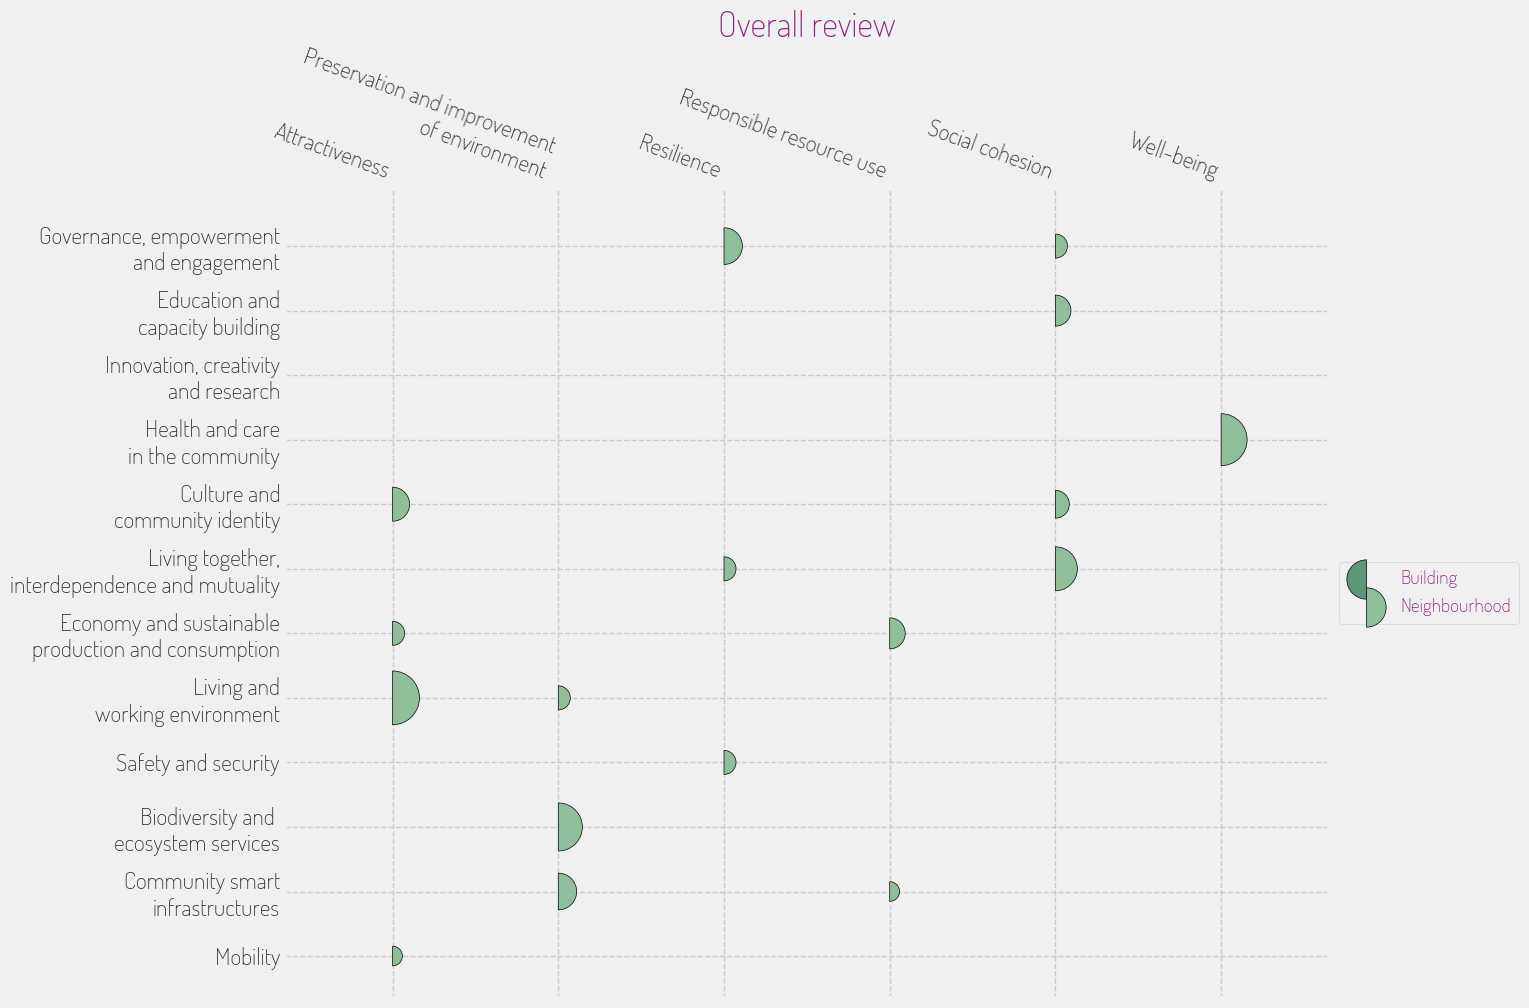

In [ ]:
D = df[df.Place == "Paris"]
dfRef = D[D.Type == "Vision"]
dfUC  = D[D.Type == "Activity"]
plt, ax = iImg.createImg(dfUC, dfRef, title="Overall review")

# Creating the reports

In [24]:
createExcel(dfRef,"iso37101_Vision.xlsx","Visions.","Across WP","Paris")
createExcel(dfUC,"iso37101_Activities.xlsx","Activities.","Across WP","Paris")

Empty dataframe, won't be able to create a report


/home/kelu/projets/pbn_37k/.venv/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


'iso37101_Activities.xlsx'

In [30]:
a = brain.integrateReview("reviews/OUT_Reviewed_-Aarhus_Activities.xlsx")
b = brain.integrateReview("reviews/OUT_Reviewed_-Aarhus_Vision.xlsx")
a.head(2)

,FromProbono,Origin,Place,Type,Source,Justification,Purpose,Issue,Scale,Score,Justification_Short,Source_Title,Reviewed,reviewBy,reviewDate,reviewsrc,timestamp
0,True,None,Aarhus,ToBeConfirmed,VisBlue flow batteries:\nVisblue will produce ...,None,Preservation and improvement of environment,Economy and sustainable production and consump...,Building,1,,VisBlue flow batteries,True,None,None,reviews/OUT_Reviewed_-Aarhus_Activities.xlsx,2025-09-14 18:19:30
1,True,None,Aarhus,ToBeConfirmed,VisBlue flow batteries:\nVisblue will produce ...,None,Preservation and improvement of environment,Economy and sustainable production and consump...,Neighbourhood,1,,VisBlue flow batteries,True,None,None,reviews/OUT_Reviewed_-Aarhus_Activities.xlsx,2025-09-14 18:19:30


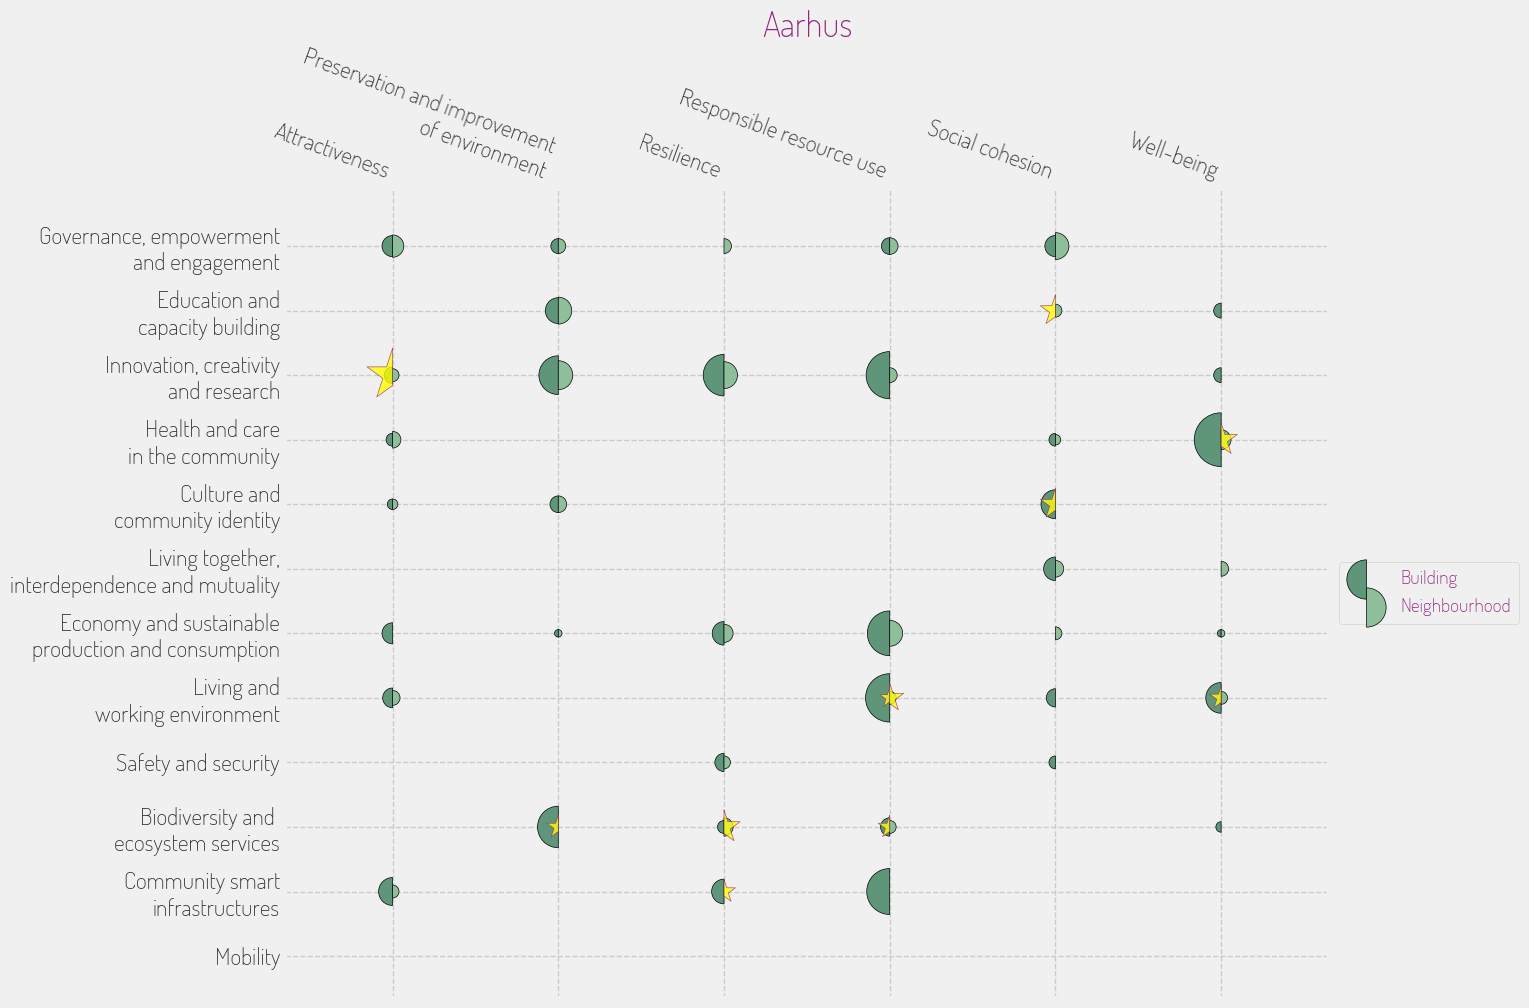

In [29]:
plt, ax = iImg.createImg(a, b, title="Aarhus")

In [32]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
